## HW3: Kernel Ridge Regression

In this notebook you will review the details of kernel ridge regression (KRR). In particular:

* How to formulate matrices and solutions to KRR
* Use scikit-learn to train a KRR model for the problem in HW2

In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, mean_absolute_error
%matplotlib inline


## Data Loading

For the first part of this HW, you will predict fuel efficiency (`mpg`) of several models of automobiles using a **single feature**.

First, let's load in the data. We're using a built in dataset for the Seaborn library so there is no external download needed.

In [59]:
# Here, we load the fuel dataset, and drop any rows that have missing data.
vehicle_data = sns.load_dataset('mpg').dropna()
vehicle_data = vehicle_data.sort_values('horsepower', ascending=True)
vehicle_data.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
19,26.0,4,97.0,46.0,1835,20.5,70,europe,volkswagen 1131 deluxe sedan
102,26.0,4,97.0,46.0,1950,21.0,73,europe,volkswagen super beetle
244,43.1,4,90.0,48.0,1985,21.5,78,europe,volkswagen rabbit custom diesel
326,43.4,4,90.0,48.0,2335,23.7,80,europe,vw dasher (diesel)
325,44.3,4,90.0,48.0,2085,21.7,80,europe,vw rabbit c (diesel)


In [60]:
vehicle_data.shape

(392, 9)

We have 392 datapoints and 8 potential features (plus our observed $y$ values, `mpg`).

Typically for regression, we want our data is nice simple arrays so we can do something like fit(x,y). For that reason, it can be helpful to just define table columns as variables for later use

In [61]:
v_mpg = vehicle_data['mpg']
v_horsepower = vehicle_data['horsepower']

Let's take a look at the data

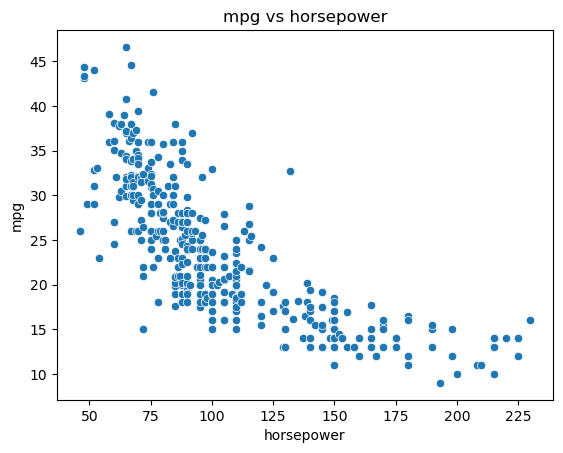

In [62]:
# Run this cell to visualize the data. 
sns.scatterplot(data=vehicle_data, x='horsepower', y='mpg');
plt.title("mpg vs horsepower");

## KRR with a Single Variable

It is evident that mpg does not depend on horsepower linearly, so you need to use nonlinear kernels for KRR. Let's review the key ideas behind KRR.

The KRR model reads

$$
\tilde{y} = \sum_{i=1}^m \alpha_i k(x_i, x),
$$

where $x_i$ is the input of the $i$th training data point, $m$ is the number of training data points, and $k(x_i, x$) is the kernal function. Like in linear regression, we would like to minimize the squared error with a ridge regularization, namely

$$
L(\alpha_i) = \sum_{i=1}^m (y_i - \tilde{y}_i)^2 + \lambda \sum_{i=1}^m \alpha_i^2,
$$
where $\lambda$ is the regularization parameter, another hyperparameter. If one sets the first derivatives of the loss function with respect to $\alpha_i$ to be zero, after some matrix algebra, one obtains the normal equation for KRR:

$$
\vec{\alpha} = ({\bf K} + \lambda {\bf I})^{-1} \vec{y},
$$
where $\vec{\alpha} = (\alpha_1, \alpha_2, \cdots, \alpha_m)^T$, $\vec{y} = (y_1, y_2, \cdots, y_m)^T$, $\bf I$ is the identity matrix, and the matrix element of the kernel matrix (a.k.a., Gram matrix) is ${\bf K}_{ij} = k(x_i, x_j)$. For the linear kernel, $\bf K = XX^T$. For other nonlinear kernels (e.g., Gaussian, polynomial, etc), one can compute $\bf K$ using its definition. 

First five predicted values at training X:
[25.87071403 25.87071403 43.4656601  43.4656601  43.4656601 ]
MSE: 12.0017
MAE: 2.5010
Correlation coefficient (r): 0.8958
R-squared (r^2): 0.8025


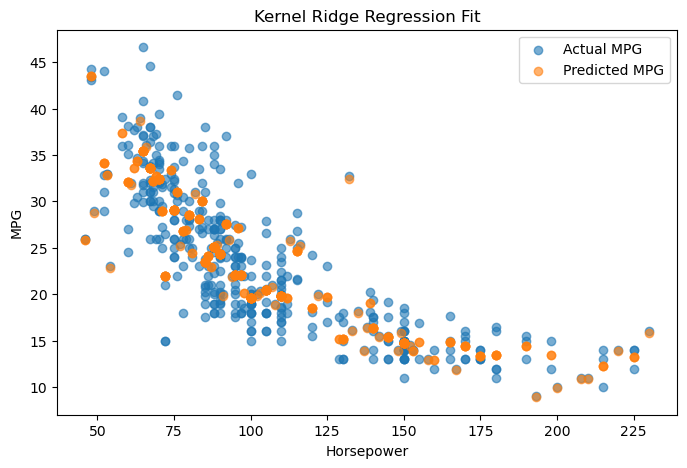

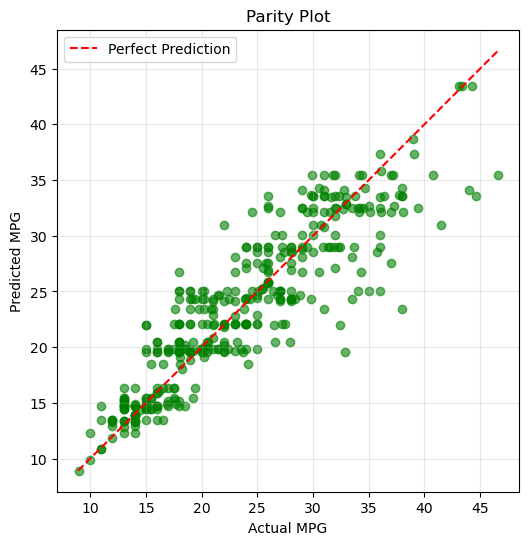

In [56]:
# Personally I like to use X and y
X = v_horsepower.values.reshape(-1, 1)  # 2D array
y = v_mpg

# Kernel Ridge with nonlinear kernel and no regularization
# Gaussian kernel (RBF)
model = KernelRidge(kernel="rbf", 
                    # degree=3, 
                    alpha=0.01, 
                    gamma=2)
model.fit(X, y)

# Predicted values at training X
y_pred = model.predict(X)
print("First five predicted values at training X:")
print(y_pred[:5])

# -----------------------------
# Compute MSE and MAE
# -----------------------------
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

# -----------------------------
# Compute correlation coefficient and R^2
# -----------------------------
r = np.corrcoef(y, y_pred)[0, 1]
r2 = r ** 2
print(f"Correlation coefficient (r): {r:.4f}")
print(f"R-squared (r^2): {r2:.4f}")

# -----------------------------
# Plot fit
# -----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Actual MPG", alpha=0.6)
plt.scatter(X, y_pred, label="Predicted MPG", alpha=0.6)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Kernel Ridge Regression Fit")
plt.legend()
plt.show()

# -----------------------------
# Parity plot: predicted vs actual
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, color='green', alpha=0.6)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Parity Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.axis('square')
plt.show()

## KRR with Multiple Variables

Clearly, mpg does not just depend on horsepower. For example, rows 3-5 all have a horsepower of 48.0, but their mpg are different (43.1, 43.4, 44.3). Other factors must also play a role. Without looking into the data closely (one should in real research), one might ignore origin and name, but consider the other 6 features. Let's do KRR with these 6 features.

First five predicted values at training X:
[25.74257426 25.74257426 42.67326733 42.97029703 43.86138614]
MSE: 0.0592
MAE: 0.2310
Correlation coefficient (r): 1.0000
R-squared (r^2): 1.0000


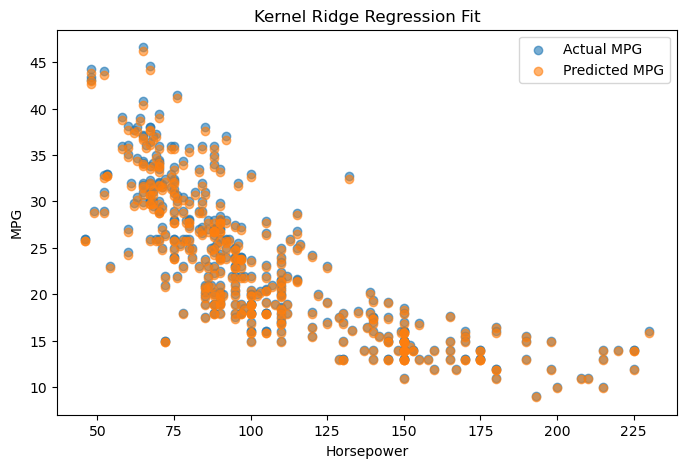

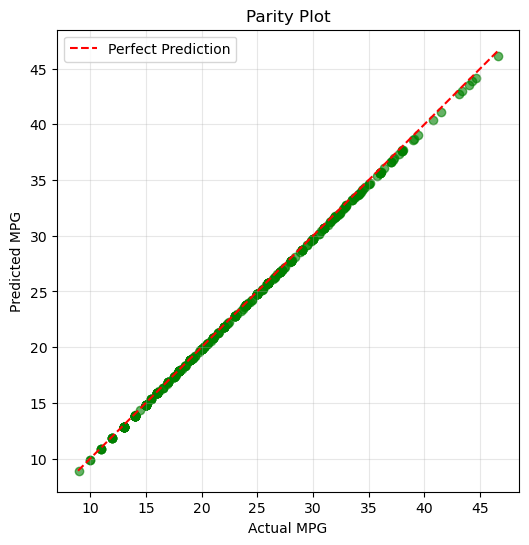

In [57]:
v_mpg = vehicle_data['mpg']
v_horsepower = vehicle_data['horsepower']
v_features = vehicle_data[['horsepower', 'cylinders', 'displacement', 'weight', 'acceleration', 'model_year']]

# Personally I like to use X and y
X = v_features
y = v_mpg

# Kernel Ridge with nonlinear kernel and no regularization
# Gaussian kernel (RBF)
model = KernelRidge(kernel="rbf", 
                    # degree=3, 
                    alpha=0.01, 
                    gamma=2)
model.fit(X, y)

# Predicted values at training X
y_pred = model.predict(X)
print("First five predicted values at training X:")
print(y_pred[:5])

# -----------------------------
# Compute MSE and MAE
# -----------------------------
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

# -----------------------------
# Compute correlation coefficient and R^2
# -----------------------------
r = np.corrcoef(y, y_pred)[0, 1]
r2 = r ** 2
print(f"Correlation coefficient (r): {r:.4f}")
print(f"R-squared (r^2): {r2:.4f}")

# -----------------------------
# Plot fit
# -----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(v_horsepower, y, label="Actual MPG", alpha=0.6)
plt.scatter(v_horsepower, y_pred, label="Predicted MPG", alpha=0.6)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Kernel Ridge Regression Fit")
plt.legend()
plt.show()

# -----------------------------
# Parity plot: predicted vs actual
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, color='green', alpha=0.6)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Parity Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.axis('square')
plt.show()